Lex Albrandt  
CS 440  
HW 3 writeup  
  

In [1]:
# Imports
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

# Part 1  
   
## 1)  
  
For the first question we model the joint distribution of pixel values  
using an autoregressive FVSBN. Using the chain rule of probability, the   
joint distribution is factorized as:  
   
$$p(x_1,x_2,\ldots,x_D)= \prod_{i=i}^{D} p(x_i \mid x_1,\ldots,x_{i-1})$$  
  
Where:  
- $x \in \{0,1\}^D$ is a binarized CIFAR-10 image
- $D=3072$ pixels
- Each pixel is modeled conditionally on previous pixels.  
  
Each conditional distribution is parameterized by a neural network and  
modeled as a Bernoulli distribution with sigmoid output:  
  
$$p(x_i=1 \mid x_{<i})=\sigma(f_{\theta}(x_{<i}))$$  
  
Where:  
- $f_{\theta}$ is the FVSBN network
- $\sigma(z)$ is the sigmoid function
  
Thus, the model outputs a probability between 0 and 1 for each
pixel. During generation, pixels are sampled sequentially from left to right using the predicted Bernoulli probabilities.  
  
Masked Linear Layers are used to enforce the autoregressive constraint,   
ensuring the each pixel depends only on previously generated pixels, and  
not on future pixels.

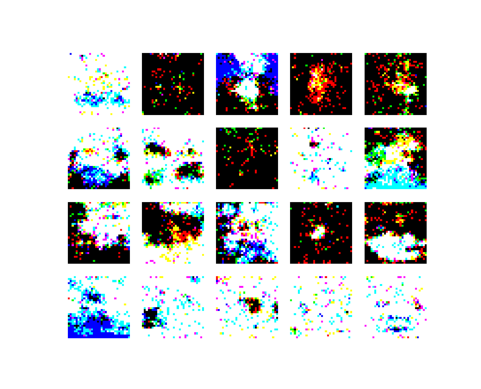

In [2]:
img = mpimg.imread("q1_1_imgs.png")
plt.axis("off")
plt.imshow(img)
plt.show()